In [1]:
import os
import re
import json
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt

import plot_utils

In [2]:
plt.rcParams['font.family'] = 'serif'
fontsize = 18
linewidth = 3
markersize = 6

# Plot hex color codes
# https://colorkit.co/palette/192e5b-1d65a6-72a2c0-00743f-f2a104-f25117/
hex_colors = ["#192e5b","#1d65a6","#72a2c0","#00743f","#f2a104","#f25117", "#623FE7", "#F0529C"]
head_type_name_to_color = {
    "Random": (hex_colors[0], '-'),
    "Dormant": (hex_colors[1], '-'),
    "HONOR": (hex_colors[5], '-'),
    "NormalizedDormant": (hex_colors[2], '-'),
    "UnnormalizedHONOR": (hex_colors[4], '-'),
    "Entropy": (hex_colors[3], '-'),
    "NormalizedEntropy": (hex_colors[6], '-'),
    # Everything below uses dashed lines
    "ValueVectorMagnitudeFirstToken": (hex_colors[0], '--'),
    "ValueVectorMagnitudeNormalizedFirstToken": (hex_colors[1], '--'),
    "ValueVectorAvgMagnitude": (hex_colors[2], '--'),
    "ValueVectorAvgNormalizedMagnitude": (hex_colors[3], '--'),
    "HeadOutputMagnitudeLastToken": (hex_colors[4], '--'),
    "HeadOutputMagnitudeNormalizedLastToken": (hex_colors[5], '--'),
    "HeadOutputMagnitudeNormalizedHeadLastToken": (hex_colors[6], '--'), 
}

# Tuples of (color, line_style, marker)
# - Every new metric gets a new color
# - Solid lines for unnormalized, dashed lines for normalized
# - 'o' markers for unnormalized, '^' markers for normalized, '*' for Head normalized
head_type_name_to_color = {
    'Random': ('black', '-', 'o'),
    'Dormant': (hex_colors[1], '-', 'o'),
    'NormalizedDormant': (hex_colors[1], '--', '^'),
    'Entropy': (hex_colors[2], '-', 'o'),
    'NormalizedEntropy': (hex_colors[2], '--', '^'),
    'ValueVectorMagnitudeFirstToken': (hex_colors[3], '-', 'o'),
    'ValueVectorMagnitudeNormalizedFirstToken': (hex_colors[3], '--', '^'),
    'ValueVectorAvgMagnitude': (hex_colors[4], '-', 'o'),
    'ValueVectorAvgNormalizedMagnitude': (hex_colors[4], '--', '^'),
    'HeadOutputMagnitudeLastToken': (hex_colors[5], '-', 'o'),
    'HeadOutputMagnitudeNormalizedLastToken': (hex_colors[5], '--', '^'),
    'HeadOutputMagnitudeNormalizedHeadLastToken': (hex_colors[5], '--', '*'),
    'UnnormalizedHONOR': (hex_colors[6], '-', 'o'),
    'HONOR': (hex_colors[6], '--', '^'),
}
head_type_classname_order = ['RandomHeads', 'DormantHeads', 'NormalizedDormantHeads', \
                             'EntropyHeads', 'NormalizedEntropyHeads', \
                             'ValueVectorMagnitudeFirstToken', 'ValueVectorMagnitudeNormalizedFirstToken', \
                             'ValueVectorAvgMagnitude', 'ValueVectorAvgNormalizedMagnitude', \
                             'HeadOutputMagnitudeLastToken', 'HeadOutputMagnitudeNormalizedLastToken', \
                             'HeadOutputMagnitudeNormalizedHeadLastToken', 'UnnormalizedHonorHeads', 'HonorHeads']
head_type_name_to_label = {
    'Random': 'Random',
    'Dormant': 'Avg Weight of First Token',
    'NormalizedDormant': 'Avg Weight of First Token (LN)',
    'Entropy': 'Avg Entropy of Query Distributions',
    'NormalizedEntropy': 'Avg Entropy of Query Distributions (LN)',
    'ValueVectorMagnitudeFirstToken': 'First Token Value Vector Norm',
    'ValueVectorMagnitudeNormalizedFirstToken': 'First Token Value Vector Norm (LN)',
    'ValueVectorAvgMagnitude': 'Avg Value Vector Norm',
    'ValueVectorAvgNormalizedMagnitude': 'Avg Value Vector Norm (LN)',
    'HeadOutputMagnitudeLastToken': 'Last Token Head Output Norm',
    'HeadOutputMagnitudeNormalizedLastToken': 'Last Token Head Output Norm (LN)',
    'HeadOutputMagnitudeNormalizedHeadLastToken': 'Last Token Head Output Norm (HN)',
    'UnnormalizedHONOR': 'Avg Head Output Norm',
    'HONOR': 'Avg Head Output Norm (LN)',
}

head_type_name_to_abb_label = {
    'Random': 'Rand',
    'Dormant': 'AWFT',
    'NormalizedDormant': 'AWFT (LN)',
    'Entropy': 'AEQD',
    'NormalizedEntropy': 'AEQD (LN)',
    'ValueVectorMagnitudeFirstToken': 'FTVVN',
    'ValueVectorMagnitudeNormalizedFirstToken': 'FTVVN (LN)',
    'ValueVectorAvgMagnitude': 'AVVN',
    'ValueVectorAvgNormalizedMagnitude': 'AVVN (LN)',
    'HeadOutputMagnitudeLastToken': 'LTHON',
    'HeadOutputMagnitudeNormalizedLastToken': 'LTHON (LN)',
    'HeadOutputMagnitudeNormalizedHeadLastToken': 'LTHON (HN)',
    'UnnormalizedHONOR': 'AHON',
    'HONOR': 'AHON (LN)',
}

In [3]:
from monkey_patch_head_types import HeadType, ThresholdHeadType, RandomHeads

def get_accuracy(data, task_id):
    if any(sub == task_id for sub in ["arc_challenge", "hellaswag", "winogrande", "mmlu"]):
        return data["results"][task_id]["acc,none"] * 100
    elif task_id == "gsm8k":
        return data["results"]["gsm8k"]["exact_match,strict-match"] * 100
    else:
        raise ValueError(f"Unknown task_id: {task_id}")

def get_model_proportion(data):
    return data["model_proportion"] * 100

def get_threshold(head_type):
    if isinstance(head_type, ThresholdHeadType):
        return head_type.threshold
    elif isinstance(head_type, RandomHeads):
        return head_type.probability
    else:
        raise ValueError(f"Unknown head_type: {head_type}")

In [4]:
# Given the data_for_intersect, find the largest x percent intersects with the baseline
#                     find the largest x percent that intersects with 1% under the baseline
def get_intersection(xs, ys, baseline):
    # Validate input
    if len(xs) < 2 or len(ys) < 2 or len(xs) != len(ys):
        print("Invalid input")
        return 0
    
    # Initialize variable to store the last intersection x-coordinate
    last_intersection = None
    
    # Check if the first point is on the baseline
    if ys[0] == baseline:
        last_intersection = xs[0]
    
    # Iterate through each segment
    for i in range(len(xs) - 1):
        y1, y2 = ys[i], ys[i+1]
        x1, x2 = xs[i], xs[i+1]
        
        # Check if the segment crosses the baseline
        if (y1 - baseline) * (y2 - baseline) < 0:
            # Calculate intersection using linear interpolation
            denom = y2 - y1
            x_intersect = x1 + (baseline - y1) * (x2 - x1) / denom
            last_intersection = x_intersect
        
        # Check if the segment's endpoint is on the baseline
        if y2 == baseline:
            last_intersection = x2
    
    # Handle case where no intersection is found
    if last_intersection is None:
        print("Doesn't intersect")
        return 0
    return last_intersection

Plot all models for a given task id:

[Model=Llama-3.2-3B, Task=mmlu, HeadType=Random, Len=7] [(0.0, 0.0, 56.202820111095285), (0.05, 5.1898900837538005, 47.52884204529269), (0.1, 10.190973107045172, 37.56587380714998), (0.15, 15.20590183986545, 30.06694203104971), (0.2, 20.17880502183035, 26.869391824526424), (0.25, 25.166753733244995, 25.744195983478136), (0.3, 30.187214379151587, 24.88961686369463)]
[Model=Llama-3.2-3B, Task=mmlu, HeadType=Dormant, Len=7] [(0.9921875, 0.0, 56.152969662441244), (0.9296875, 5.499018908312523, 55.533399800598204), (0.89453125, 11.738878837300172, 54.807007548782224), (0.859375, 17.845218983062363, 53.204671699188154), (0.828125, 23.508369009394695, 51.11807434838342), (0.796875, 28.80920527326164, 46.232730380287705), (0.765625, 32.301838591305234, 38.570004272895595)]
[Model=Llama-3.2-3B, Task=mmlu, HeadType=NormalizedDormant, Len=7] [(2.59375, 0.0, 56.152969662441244), (1.3828125, 5.271573399249103, 50.83321464178891), (1.2734375, 11.201985967415865, 45.44224469448797), (1.2265625, 16.04

/tmp/ipykernel_1966317/2588079890.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(ys, xs) / (max(xs) - min(xs))


[Model=Llama-3.2-3B-Instruct, Task=mmlu, HeadType=Random, Len=7] [(0.0, 0.0, 61.28044438114229), (0.05, 5.17171228105941, 56.20994160376015), (0.1, 10.165054873180095, 49.87181313203247), (0.15, 15.171892784941305, 41.64648910411623), (0.2, 20.148108744032754, 33.39980059820538), (0.25, 25.127329561863988, 27.5957840763424), (0.3, 30.1663821076058, 25.758438968807862)]
[Model=Llama-3.2-3B-Instruct, Task=mmlu, HeadType=Dormant, Len=7] [(1.0, 0.0, 61.24483691781798), (0.91796875, 6.265077383075955, 60.39737929069933), (0.890625, 14.244039124747292, 58.85201538242416), (0.8671875, 20.67417138100335, 56.4093433983763), (0.84375, 26.69317950155446, 54.272895598917536), (0.81640625, 32.66368516725278, 49.116934909557045), (0.79296875, 36.72670013420994, 42.81441390115368)]
[Model=Llama-3.2-3B-Instruct, Task=mmlu, HeadType=NormalizedDormant, Len=7] [(2.265625, 0.0, 61.24483691781798), (1.3046875, 5.251282639348996, 49.900299102691925), (1.21875, 11.835798804002515, 39.616863694630396), (1.179

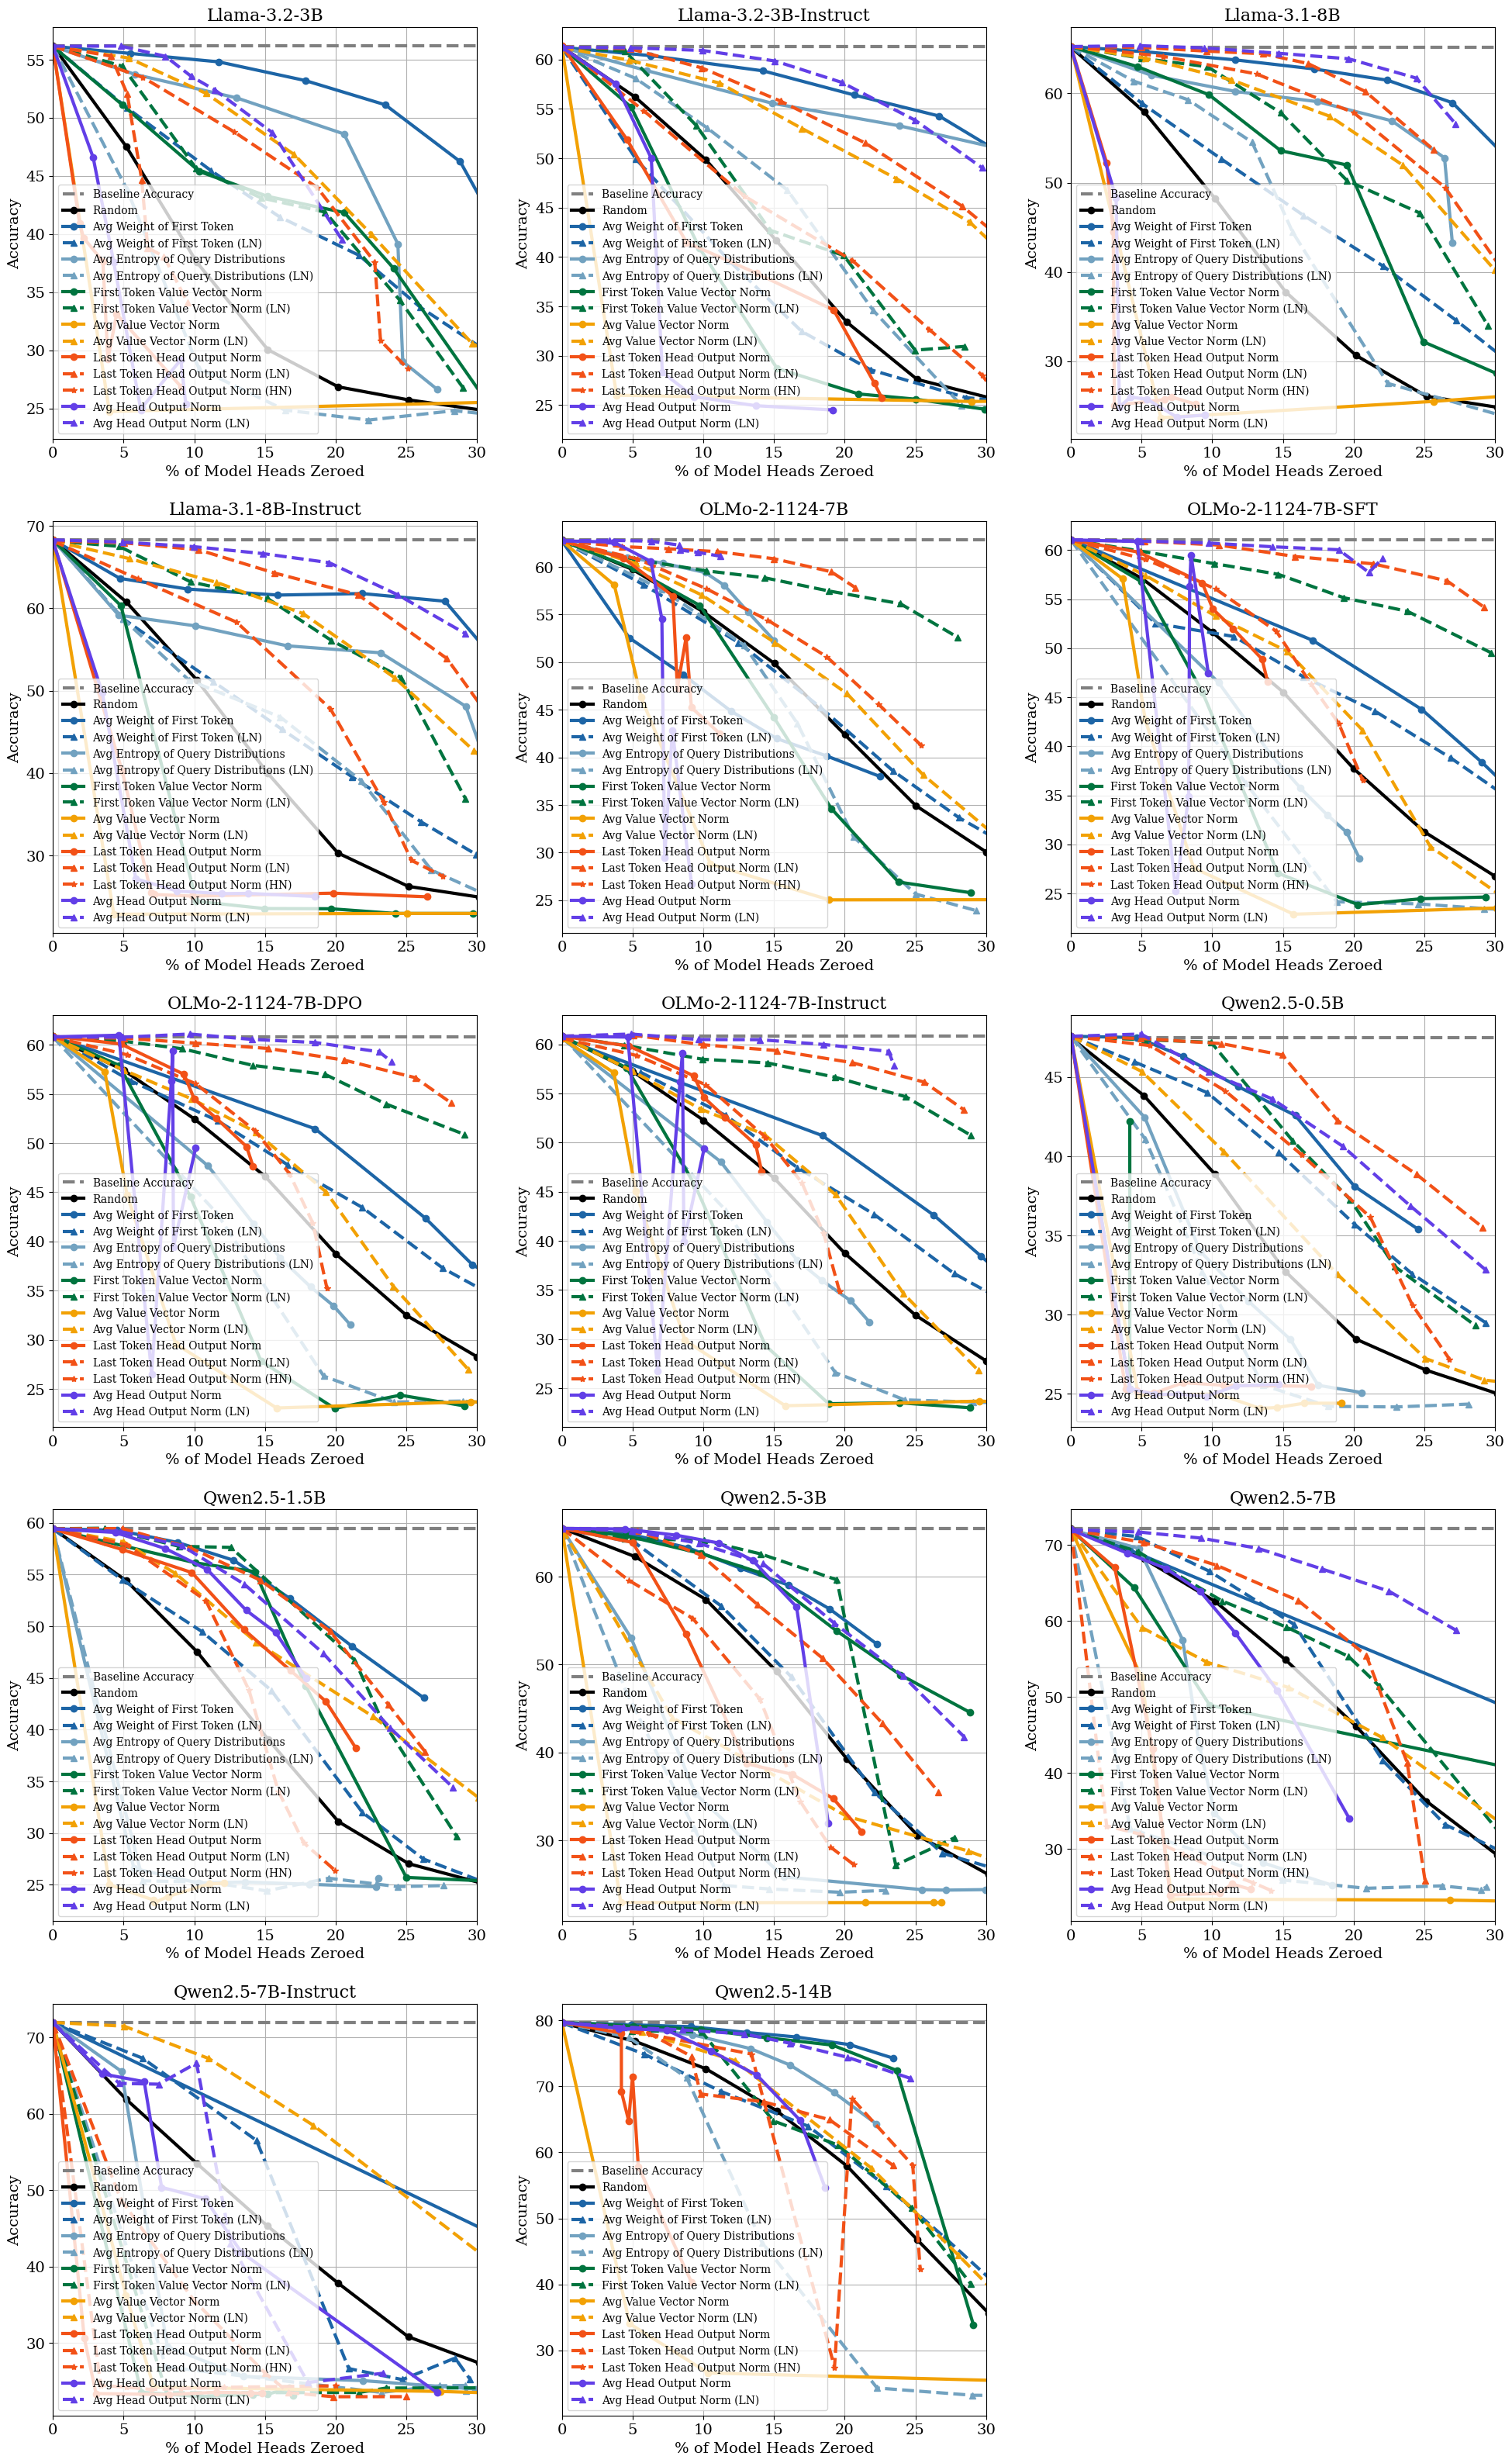

In [10]:
task_id = 'mmlu'
results_dir = Path("results-2025-09-20-attention-heads-drop")
model_ids = ['meta-llama/Llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct', 'meta-llama/Llama-3.1-8B', 'meta-llama/Llama-3.1-8B-Instruct',\
             'allenai/OLMo-2-1124-7B', 'allenai/OLMo-2-1124-7B-SFT', 'allenai/OLMo-2-1124-7B-DPO', 'allenai/OLMo-2-1124-7B-Instruct',\
             'Qwen/Qwen2.5-0.5B', 'Qwen/Qwen2.5-1.5B', 'Qwen/Qwen2.5-3B', 'Qwen/Qwen2.5-7B', 'Qwen/Qwen2.5-7B-Instruct', 'Qwen/Qwen2.5-14B']
num_models_dir = len(model_ids)

cols_per_row = 3
rows = (num_models_dir // cols_per_row) + (1 if num_models_dir % cols_per_row != 0 else 0)

fig, axs = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 8, rows * 8))

# Log AUCs for each model and head type
aucs = dict()  # model_name -> head_type_name -> AUC value
largest_percent_to_be_within_1pc_dormant = dict()  # model_name -> percent
largest_percent_to_be_within_1pc_ours = dict()  # model_name -> (head_type_name, percent)
largest_percent_to_be_within_1pc = dict()  # model_name -> (head_type_name, percent)

def compute_normalized_auc(xs, ys):
    # Compute the AUC using the trapezoidal rule
    return np.trapz(ys, xs) / (max(xs) - min(xs))

for i, model_id in enumerate(model_ids):
    row_idx = i // cols_per_row
    col_idx = i % cols_per_row

    model_name = model_id.split('/')[-1]
    axs[row_idx, col_idx].set_title(model_name, fontsize=plot_utils.subtitlesize)
    task_dir = results_dir / model_id.replace('/', '_') / task_id

    # Plot baseline accuracy line for RandomHeads:0.0
    if (task_dir / "RandomHeads:0.0.json").exists():
        with open(task_dir / "RandomHeads:0.0.json") as f:
            data = json.load(f)
            base_accuracy = get_accuracy(data, task_id)
            axs[row_idx, col_idx].axhline(y=base_accuracy, color='gray', linestyle='--', linewidth=linewidth, label='Baseline Accuracy')

    current_data = {} # dict of HeadType -> List[(threshold, model_proportion, accuracy)]
    for head_type_classname in head_type_classname_order:
        for file in task_dir.glob(f"{head_type_classname}:*.json"):
            head_type = HeadType.from_string(file.stem) # file.stem looks like RandomHeads:0.2
            with open(file) as f:
                data = json.load(f)
                acc = get_accuracy(data, task_id)
                model_proportion = get_model_proportion(data)
                if head_type.name not in current_data:
                    current_data[head_type.name] = []
                threshold = get_threshold(head_type)
                current_data[head_type.name].append((threshold, model_proportion, acc))

    # after collecting all data for the current task, sort it by model_proportion and plot
    for head_type_name, values in current_data.items():
        values.sort(key=lambda x: x[1])  # sort by model_proportion
        print(f'[Model={model_name}, Task={task_id}, HeadType={head_type_name}, Len={len(values)}] {values}')
        ts, xs, ys = zip(*values)
        axs[row_idx, col_idx].plot(xs, ys, label=head_type_name_to_label[head_type_name],
                                   marker=head_type_name_to_color[head_type_name][2], 
                                   color=head_type_name_to_color[head_type_name][0], 
                                   linewidth=linewidth, markersize=markersize, linestyle=head_type_name_to_color[head_type_name][1])
        axs[row_idx, col_idx].set_xlabel("% of Model Heads Zeroed", fontsize=plot_utils.ticklabelsize)
        axs[row_idx, col_idx].set_ylabel("Accuracy", fontsize=plot_utils.ticklabelsize)
        axs[row_idx, col_idx].tick_params(axis='both', which='major', labelsize=plot_utils.ticklabelsize)
        axs[row_idx, col_idx].grid(True)
        axs[row_idx, col_idx].set_xlim(0, 30)

        # Calculate and log AUC
        auc_value = compute_normalized_auc(xs, ys)
        if model_name not in aucs:
            aucs[model_name] = {}
        aucs[model_name][head_type_name] = auc_value

        # Calculate largest percent to be within 1% of baseline for Dormant and our best method
        largest_percent = get_intersection(xs, ys, base_accuracy - 1)
        if head_type_name == "Dormant":
            largest_percent_to_be_within_1pc_dormant[model_name] = largest_percent
        else:
            if model_name not in largest_percent_to_be_within_1pc_ours or \
               largest_percent > largest_percent_to_be_within_1pc_ours[model_name][1]:
                largest_percent_to_be_within_1pc_ours[model_name] = (head_type_name, largest_percent)
        # Calculate largest percent to be within 1% of baseline for any method
        if model_name not in largest_percent_to_be_within_1pc or \
           largest_percent > largest_percent_to_be_within_1pc[model_name][1]:
            largest_percent_to_be_within_1pc[model_name] = (head_type_name, largest_percent)

    axs[row_idx, col_idx].legend(loc='lower left')

# Turn off remaining empty subplots
for j in range(i+1, rows * cols_per_row):
    row_idx = j // cols_per_row
    col_idx = j % cols_per_row
    axs[row_idx, col_idx].axis('off')

In [6]:
# Print Table of largest percent to be within 1% of baseline, in LaTeX format
# print("Model Name & Avg Weight of First Token & Our Best Scoring Function (Difference) & Best Scoring Function \\\\")
dormant = []
ours = []
for model_name in model_ids:
    model_name = model_name.split('/')[-1]
    dormant_percent = largest_percent_to_be_within_1pc_dormant[model_name]
    ours_head_type, ours_percent = largest_percent_to_be_within_1pc_ours[model_name]
    best_head_type, best_percent = largest_percent_to_be_within_1pc[model_name]
    difference = ours_percent - dormant_percent
    print(f"{model_name} & {dormant_percent:.2f} & {ours_percent:.2f} \\textcolor{{gray}}{{({'+' if difference > 0 else ''}{difference:.2f})}} & {head_type_name_to_label[best_head_type]} \\\\")
    dormant.append(dormant_percent)
    ours.append(ours_percent)
print("\\midrule")
print(f"Average & {np.mean(dormant):.2f} & {np.mean(ours):.2f} \\textcolor{{gray}}{{({'+' if np.mean(ours) - np.mean(dormant) > 0 else ''}{np.mean(ours) - np.mean(dormant):.2f})}} & - \\\\")

Llama-3.2-3B & 8.34 & 8.05 \textcolor{gray}{(-0.29)} & Avg Weight of First Token \\
Llama-3.2-3B-Instruct & 6.87 & 13.04 \textcolor{gray}{(+6.17)} & Avg Head Output Norm (LN) \\
Llama-3.1-8B & 8.56 & 17.11 \textcolor{gray}{(+8.55)} & Avg Head Output Norm (LN) \\
Llama-3.1-8B-Instruct & 1.01 & 10.97 \textcolor{gray}{(+9.95)} & Avg Head Output Norm (LN) \\
OLMo-2-1124-7B & 0.42 & 8.34 \textcolor{gray}{(+7.93)} & Avg Head Output Norm (LN) \\
OLMo-2-1124-7B-SFT & 1.70 & 18.95 \textcolor{gray}{(+17.25)} & Avg Head Output Norm (LN) \\
OLMo-2-1124-7B-DPO & 2.14 & 20.60 \textcolor{gray}{(+18.46)} & Avg Head Output Norm (LN) \\
OLMo-2-1124-7B-Instruct & 1.46 & 19.54 \textcolor{gray}{(+18.07)} & Avg Head Output Norm (LN) \\
Qwen2.5-0.5B & 7.43 & 14.42 \textcolor{gray}{(+6.99)} & Last Token Head Output Norm (LN) \\
Qwen2.5-1.5B & 7.55 & 7.49 \textcolor{gray}{(-0.07)} & Avg Weight of First Token \\
Qwen2.5-3B & 5.67 & 8.78 \textcolor{gray}{(+3.11)} & Avg Head Output Norm \\
Qwen2.5-7B & 1.25 & 7.5

Normalized AUCs for model Llama-3.2-3B:
  Dormant: 52.09
  HONOR: 51.67
  Entropy: 48.79
  HeadOutputMagnitudeNormalizedLastToken: 48.56
  HeadOutputMagnitudeNormalizedHeadLastToken: 47.36
  ValueVectorAvgNormalizedMagnitude: 44.13
  ValueVectorMagnitudeNormalizedFirstToken: 43.68
  ValueVectorMagnitudeFirstToken: 43.04
  NormalizedDormant: 42.67
  UnnormalizedHONOR: 37.62
  HeadOutputMagnitudeLastToken: 35.69
  Random: 34.83
  NormalizedEntropy: 30.80
  ValueVectorAvgMagnitude: 26.52

Normalized AUCs for model Llama-3.2-3B-Instruct:
  HONOR: 58.15
  Dormant: 55.98
  Entropy: 53.70
  HeadOutputMagnitudeNormalizedLastToken: 52.55
  ValueVectorAvgNormalizedMagnitude: 50.96
  ValueVectorMagnitudeNormalizedFirstToken: 46.10
  HeadOutputMagnitudeNormalizedHeadLastToken: 44.19
  HeadOutputMagnitudeLastToken: 42.31
  Random: 42.13
  NormalizedEntropy: 41.78
  ValueVectorMagnitudeFirstToken: 36.56
  UnnormalizedHONOR: 36.43
  NormalizedDormant: 36.38
  ValueVectorAvgMagnitude: 26.73

Normalize

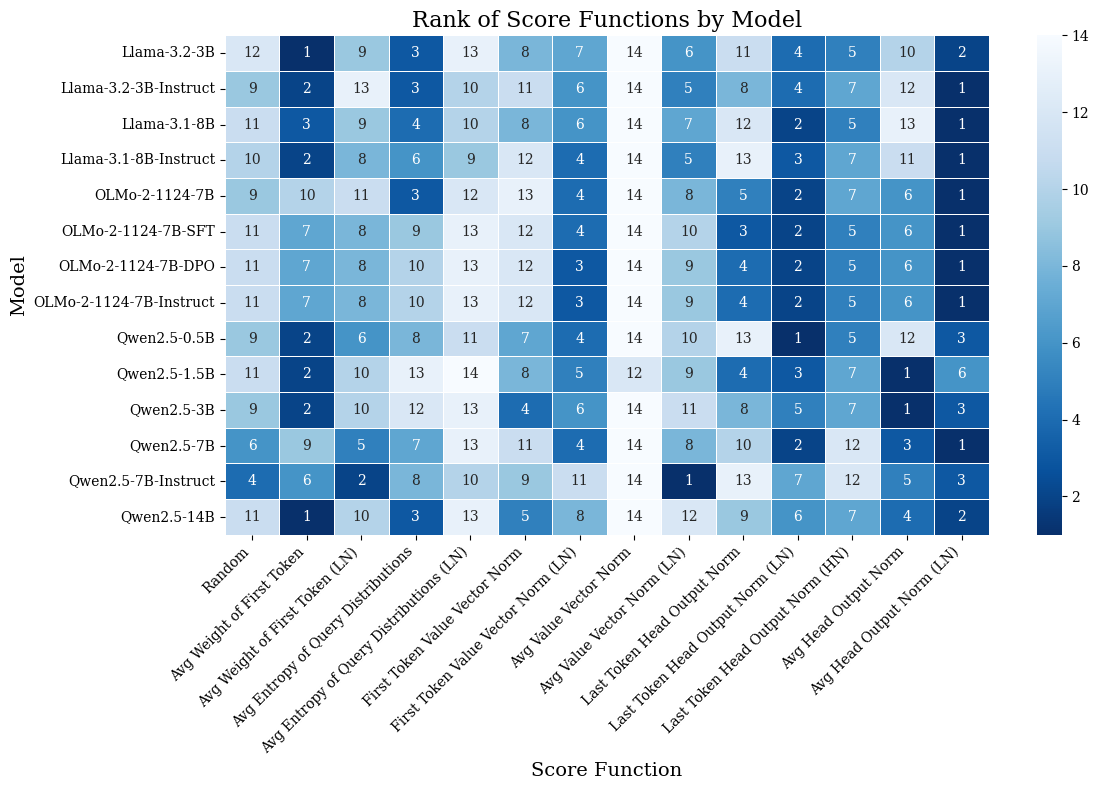

In [ ]:
# If any AUCs are nan, replace with 0
for model_name, head_type_aucs in aucs.items():
    for head_type_name, auc_value in head_type_aucs.items():
        if np.isnan(auc_value):
            print(f'Warning: AUC for model {model_name}, head type {head_type_name} is NaN. Replacing with 0.')
            aucs[model_name][head_type_name] = 0.0
            
# For each model name, print the AUCs in order of head type with the largest AUC first
ranks = {}
for model_name, head_type_aucs in aucs.items():
    print(f"Normalized AUCs for model {model_name}:")
    sorted_aucs = sorted(head_type_aucs.items(), key=lambda x: x[1], reverse=True)
    # Create a dictionary mapping head_type_name to its rank (1-indexed)
    ranks[model_name] = {head_type: i + 1 for i, (head_type, auc) in enumerate(sorted_aucs)}
    for head_type_name, auc_value in sorted_aucs:
        print(f"  {head_type_name}: {auc_value:.2f}")
    print()

# Create the heatmap
fig, ax = plt.subplots(figsize=(12, 8))
import seaborn as sns
import pandas as pd

# Convert ranks to a pandas DataFrame for easier plotting
rank_df = pd.DataFrame(ranks).T  # Transpose to have models as rows

# Reorder the columns to match your specified order
rank_df = rank_df[list(head_type_name_to_label.keys())]

sns.heatmap(
    rank_df,
    annot=True,          # Show the rank numbers in the cells
    cmap='Blues_r',        # Use the 'Blues' colormap
    fmt='d',             # Format annotations as integers
    linewidths=.5,       # Add lines between cells
    ax=ax
)

# Customize the plot
ax.set_title('Rank of Score Functions', fontsize=16)
ax.set_xticklabels(head_type_name_to_label.values(), rotation=45, ha='right')  # Rotate x-axis labels for better readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xlabel('Score Function', fontsize=14)
ax.set_ylabel('Model', fontsize=14)

# Ensure everything fits without overlapping
plt.tight_layout()

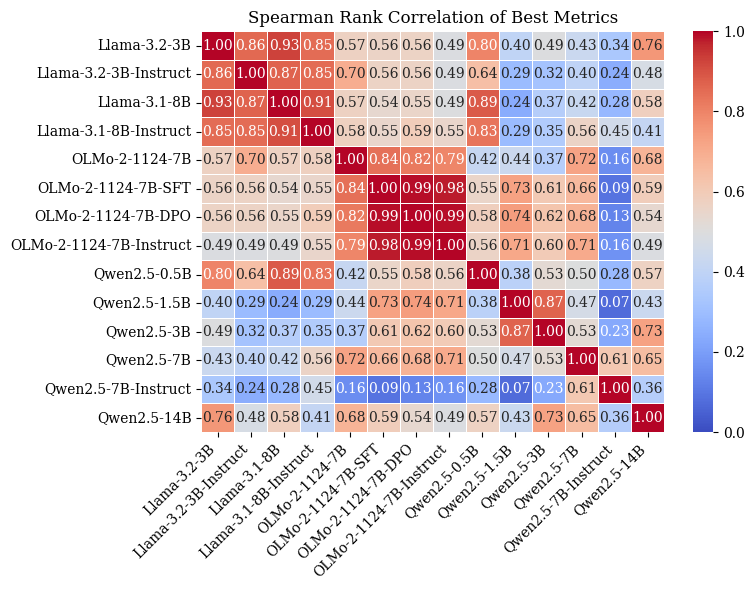

In [6]:
import pandas as pd
from typing import Dict
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_rank_correlation(aucs: Dict[str, Dict[str, float]]) -> pd.DataFrame:
    """
    Calculates the Spearman rank correlation between models based on AUC scores.

    This function takes a nested dictionary where the outer keys are model names
    and the inner keys are categories (e.g., head types), with AUC values as
    the final data. It converts this structure into a pandas DataFrame and then
    computes the pairwise Spearman rank correlation between all models.

    Args:
        aucs: A nested dictionary in the format:
              {model_name: {head_type_name: AUC_value, ...}, ...}

    Returns:
        A pandas DataFrame representing the Spearman rank correlation matrix,
        where both the index and columns are model names.
    """
    # 1. Convert the nested dictionary into a pandas DataFrame.
    #    The outer keys (model names) become columns, and the inner keys
    #    (head types) become the index. This aligns the data for comparison.
    df = pd.DataFrame(aucs)

    # 2. Compute the Spearman rank correlation matrix.
    #    The .corr() method calculates the pairwise correlation of columns.
    #    By specifying method='spearman', it first ranks the data within
    #    each column and then computes the Pearson correlation on those ranks.
    rank_correlation_matrix = df.corr(method='spearman')

    # 3. Sort the matrix by model name (alphabetically) for consistent ordering.
    #    This makes the resulting heatmap easier to read.
    model_names_order = ['Llama-3.2-3B', 'Llama-3.2-3B-Instruct', 'Llama-3.1-8B', 'Llama-3.1-8B-Instruct',\
                         'OLMo-2-1124-7B', 'OLMo-2-1124-7B-SFT', 'OLMo-2-1124-7B-DPO', 'OLMo-2-1124-7B-Instruct',\
                         'Qwen2.5-0.5B', 'Qwen2.5-1.5B', 'Qwen2.5-3B', 'Qwen2.5-7B', 'Qwen2.5-7B-Instruct', 'Qwen2.5-14B']
    sorted_matrix = rank_correlation_matrix.reindex(index=model_names_order, columns=model_names_order)

    return sorted_matrix

def plot_correlation_matrix(correlation_matrix: pd.DataFrame):
    """
    Plots a correlation matrix using a seaborn heatmap.

    Args:
        correlation_matrix: A pandas DataFrame containing the correlation values.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        correlation_matrix,
        annot=True,          # Display the correlation values on the heatmap
        cmap='coolwarm',     # Use a color map that shows positive/negative correlation clearly
        fmt=".2f",           # Format annotations to two decimal places
        linewidths=.5,
        # colorbar should start at -1 and end at 1
        vmin=0, vmax=1
    )
    plt.title('Spearman Rank Correlation of Best Metrics')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()   # Adjust plot to ensure everything fits without overlapping
    plt.show()


# Call the function with the sample data
correlation_results = calculate_rank_correlation(aucs)

# Print the resulting correlation matrix
# print("--- Spearman Rank Correlation Matrix ---")
# print(correlation_results)

# Plot the correlation matrix
# print("\nDisplaying correlation matrix plot...")
plot_correlation_matrix(correlation_results)



Use IoU between the top 5 methods of each model to plot a similarity matrix

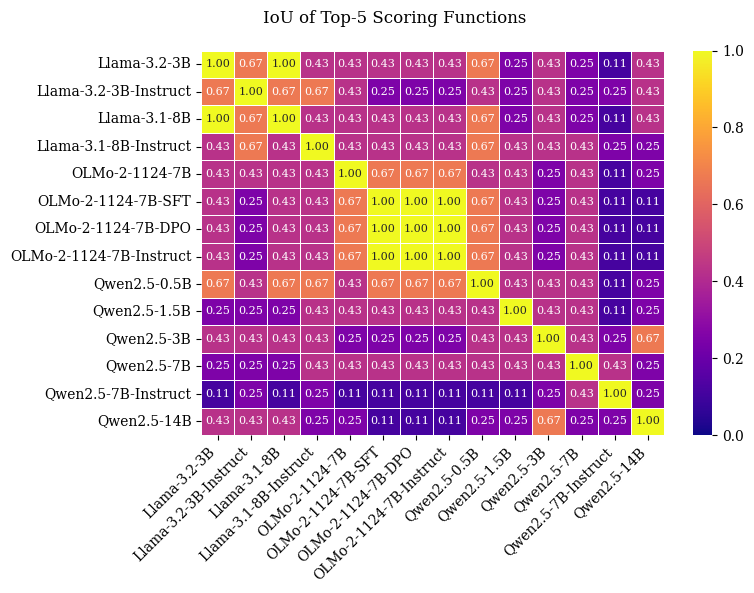

In [32]:
import seaborn as sns

topk = 5

# Compute similarity matrix using IoU of topk head types
similarity_matrix = np.zeros((len(model_ids), len(model_ids)))
for i, model_id_1 in enumerate(model_ids):
    model_name_1 = model_id_1.split('/')[-1]
    for j, model_id_2 in enumerate(model_ids):
        model_name_2 = model_id_2.split('/')[-1]
        topk_head_types_1 = set([k for k, _ in sorted(aucs[model_name_1].items(), key=lambda x: x[1], reverse=True)][:topk])
        topk_head_types_2 = set([k for k, _ in sorted(aucs[model_name_2].items(), key=lambda x: x[1], reverse=True)][:topk])
        
        intersection = len(topk_head_types_1.intersection(topk_head_types_2))
        union = len(topk_head_types_1.union(topk_head_types_2))
        iou = intersection / union if union > 0 else 0
        similarity_matrix[i, j] = iou

# Plot the similarity matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    ax=ax,
    data=similarity_matrix,
    annot=True,          # Display the correlation values on the heatmap
    annot_kws={"size": 8},
    cmap='plasma',     # Use a color map that shows positive/negative correlation clearly
    fmt=".2f",           # Format annotations to two decimal places
    linewidths=.5,
    xticklabels=[model_id.split('/')[-1] for model_id in model_ids],
    yticklabels=[model_id.split('/')[-1] for model_id in model_ids],
    vmin=0, vmax=1
)
fig.suptitle(f'IoU of Top-{topk} Scoring Functions')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()   # Adjust plot to ensure everything fits without overlapping
plt.show()
# fig.savefig("2025-iclr-iou-similarity-matrix.png", dpi=400)

Create figure with only the top-3 metrics for 3 base model types

[Model=Llama-3.1-8B-Instruct, Task=mmlu, HeadType=Random, Len=7] [(0.0, 0.0, 68.32360062669134), (0.05, 5.178721737870139, 60.8033043725965), (0.1, 10.179042264983947, 51.31035465033471), (0.15, 15.185181056011416, 40.001424298532974), (0.2, 20.162765061987155, 30.287708303660448), (0.25, 25.137352836246873, 26.23557897735365), (0.3, 30.171175414734215, 24.925224327018945)]
[Model=Llama-3.1-8B-Instruct, Task=mmlu, HeadType=HONOR, Len=7] [(0.12451171875, 0.0, 68.32360062669134), (0.34375, 4.9400335577952195, 68.03874092009686), (0.451171875, 9.960310381733855, 67.4975074775673), (0.53515625, 14.865970890563682, 66.65004985044865), (0.609375, 19.537409694969675, 65.55333998005982), (0.67578125, 24.39407833125223, 61.64364050705028), (0.73046875, 29.14808770736711, 56.96481982623558)]
[Model=Llama-3.1-8B-Instruct, Task=mmlu, HeadType=Dormant, Len=7] [(0.984375, 0.0, 68.32360062669134), (0.91796875, 4.7366521361041745, 63.64477994587665), (0.89453125, 9.51723739074206, 62.348668280871664),

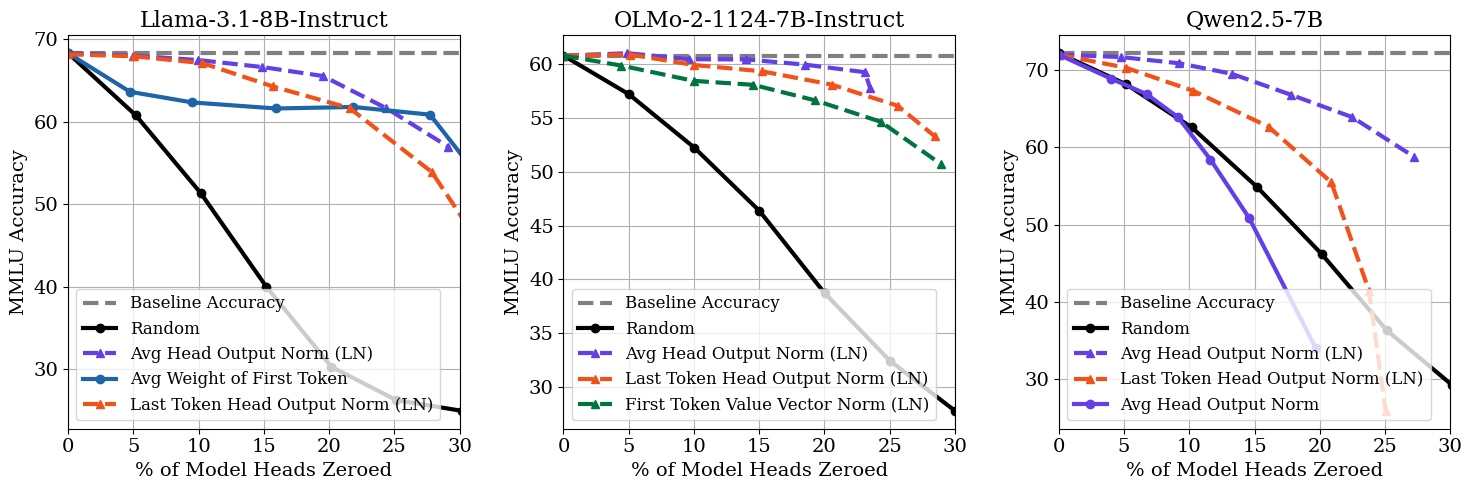

In [23]:
import plot_utils

fig, axs = plt.subplots(1, 3, figsize=(5*3, 5))
model_ids_to_plot = ['meta-llama/Llama-3.1-8B-Instruct', 'allenai/OLMo-2-1124-7B-Instruct', 'Qwen/Qwen2.5-7B']
top_k_methods = 3

for ax, model_id in zip(axs, model_ids_to_plot):
    task_dir = results_dir / model_id.replace('/', '_') / task_id
    model_name = model_id.split('/')[-1]
    ax.set_title(model_name, fontsize=plot_utils.subtitlesize)

    # Horizontal dotted line at the accuracy of the model with no heads dropped (RandomHeads:0.0)
    with open(task_dir / "RandomHeads:0.0.json") as f:
        data = json.load(f)
        base_accuracy = get_accuracy(data, task_id)
        ax.axhline(y=base_accuracy, color='gray', linestyle='--', linewidth=linewidth, label='Baseline Accuracy')

    # Get sorted AUCs for the model and choose the top-k methods
    sorted_aucs = sorted(aucs[model_name].items(), key=lambda x: x[1], reverse=True)[:top_k_methods]
    all_head_types = ['Random'] + [head_type for head_type, _ in sorted_aucs if head_type != 'Random']


    for head_type_name in all_head_types:
        # Find the corresponding data points
        current_data = {} # dict of HeadType -> List[(threshold, model_proportion, accuracy)]\
        for file in sorted(task_dir.glob(f"*.json")):
            head_type = HeadType.from_string(file.stem) # file.stem looks like RandomHeads:0.2
            if head_type.name != head_type_name:
                continue                                # skip files that are not the current head type we want to plot
            with open(file) as f:
                data = json.load(f)
                acc = get_accuracy(data, task_id)
                model_proportion = get_model_proportion(data)
                threshold = get_threshold(head_type)
                if head_type.name not in current_data:
                    current_data[head_type.name] = []
                current_data[head_type.name].append((threshold, model_proportion, acc))
        
        # after collecting all data for the current task, sort it by model_proportion and plot
        for head_type_name, values in current_data.items():
            values.sort(key=lambda x: x[1])  # sort by model_proportion
            print(f'[Model={model_name}, Task={task_id}, HeadType={head_type_name}, Len={len(values)}] {values}')
            ts, xs, ys = zip(*values)
            ax.plot(xs, ys, label=head_type_name_to_label[head_type_name],
                    marker=head_type_name_to_color[head_type_name][2], 
                    color=head_type_name_to_color[head_type_name][0], linewidth=linewidth, markersize=markersize, 
                    linestyle=head_type_name_to_color[head_type_name][1])
            if model_name == 'Qwen2.5-7B-Instruct':
                print(f'Plotting {head_type_name_to_label[head_type_name]} for {model_name}\n{xs=}\n{ys=}')
            ax.set_xlabel("% of Model Heads Zeroed", fontsize=plot_utils.ticklabelsize)
            ax.set_ylabel("MMLU Accuracy", fontsize=plot_utils.ticklabelsize)
            ax.grid(True)
            ax.set_xlim(0, 30)
            ax.tick_params(axis='both', which='major', labelsize=plot_utils.ticklabelsize)
        
    ax.legend(fontsize=plot_utils.ticklabelsize-2, loc='lower left')

plt.tight_layout()
plt.show()
# fig.savefig("2025-iclr-accuracy-vs-percent-of-heads-zeroed.png", dpi=300)
    